# Swiss calibration — car edge weights against observed trip times

Iteratively calibrates the per-edge duration formula for cars against
Google-Maps-derived point-to-point travel times. Uses the consolidated
car graph from `prepare/1_download.ipynb` (already carries per-node
`is_traffic_signal`, `is_degree_3`, `is_degree_4`) and the H3 cells
from `prepare/3_aggregate_to_cells.ipynb` (for per-node density).

**Calibration model** (see `aperta.calibration` module docstring):

```
trip_time = α · baseline_time
          + Σ_m coef_m · (baseline_time · m_avg_along_path)
          + Σ_a coef_a · (a_sum_along_path)
          + Σ_e coef_e · (e_at_origin + e_at_destination)
          + constant
```

`baseline_time` is the per-edge length / speed using OSM `maxspeed` +
per-highway-class fallback (same `HWY_SPEEDS` as `prepare/4_edge_weights`).
This stays unchanged across iterations — the calibration learns the
multiplicative correction `α` and the per-feature coefficients.

**Features used here** (all already on the consolidated graph + cells —
`prepare/4_edge_weights` uses the same set):

| Feature                | Kind               | Per-edge unit |
|------------------------|--------------------|---------------|
| `density_norm`         | multiplier         | dimensionless |
| `is_degree_3`          | additive_route     | "per edge ≥3-way" |
| `is_degree_4`          | additive_route     | "per edge ≥4-way" |
| `is_traffic_signal`    | additive_route     | "per signalised edge" |
| `density_norm` (node)  | additive_endpoint  | secs per density at orig + dest |
| `snap_dist_orig/_dest` | additive_endpoint  | secs per metre of first-mile |

**Ground truth**: Google-Maps `car_pessimistic.csv` (~50 k legs), columns
`orig_x, orig_y, dest_x, dest_y, time_measured, dist_measured, dist_line`.
Origin coordinates are derived from the protected MTMC survey, so this
specific data file isn't public — the workflow itself is the reusable
part. Replacement data with the same schema would slot in directly.

In [15]:
import warnings
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import osmnx as ox
import pandas as pd
from shapely.geometry import Point

from aperta import calibration, geo_processing, network_processing

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning, module='geopandas')

PREPARED_DIR = Path('data/prepared')
GROUND_TRUTH_PATH = Path('data/ground_truth/car_pessimistic.csv')
CRS_METRIC = 'EPSG:2056'

## 1. Load graph + cells + ground truth

In [16]:
car_graph = network_processing.load_consolidated_graphml(
    PREPARED_DIR / 'car_graph.graphml')
print(f"Car graph: {car_graph.number_of_nodes():,} nodes / "
      f"{car_graph.number_of_edges():,} edges")

cells = gpd.read_file(PREPARED_DIR / 'cells.gpkg').set_index('cell_id')
cells['pop_plus_emp'] = cells['population'] + cells['employment_total']
print(f"Cells: {len(cells):,}")

legs = pd.read_csv(GROUND_TRUTH_PATH)
print(f"Ground-truth legs: {len(legs):,} "
      f"(median time {legs['time_measured'].median():.0f} s, "
      f"median dist {legs['dist_measured'].median():.0f} m)")

Car graph: 25,069 nodes / 67,338 edges
Cells: 95,658
Ground-truth legs: 49,773 (median time 671 s, median dist 5685 m)


## 2. Baseline speed per edge (km/h)

`ox.add_edge_speeds` reads OSM `maxspeed` where available and falls back
to a per-highway-class default. Same dict as `prepare/4_edge_weights`.

In [17]:
HWY_SPEEDS = {
    'motorway': 120, 'motorway_link': 80,
    'trunk': 100,    'trunk_link': 60,
    'primary': 80,   'primary_link': 50,
    'secondary': 50, 'secondary_link': 40,
    'tertiary': 50,  'tertiary_link': 40,
    'unclassified': 50,
    'residential': 30,
    'living_street': 20,
    'service': 30,
    'road': 30,
    'busway': 30,
}
ox.add_edge_speeds(car_graph, hwy_speeds=HWY_SPEEDS)
speeds = np.array([float(d['speed_kph'])
                   for _, _, d in car_graph.edges(data=True)])
print(f"Baseline edge speeds: median {np.median(speeds):.0f} km/h, "
      f"range {speeds.min():.0f}–{speeds.max():.0f} km/h.")

Baseline edge speeds: median 30 km/h, range 10–120 km/h.


## 3. Per-node density + propagate features to edges

- **Density**: sqrt((pop+emp per km² within 1 km) / 10 000); same formula
  as `prepare/4_edge_weights`.
- **Intersection + signal flags**: already on the consolidated graph
  from `prepare/1_download` as integer flags (`is_degree_3` /
  `is_degree_4` / `is_traffic_signal`).

For features that need to enter the calibration as a *per-edge*
attribute (multiplier or additive_route), we propagate the per-node value
to the edge via the mean of its two endpoints — same logic as
`prepare/4_edge_weights`.

In [18]:
# 3a. Per-node density.
node_xy = gpd.GeoDataFrame(
    {'node_id': list(car_graph.nodes)},
    geometry=[Point(float(car_graph.nodes[n]['x']),
                    float(car_graph.nodes[n]['y']))
              for n in car_graph.nodes],
    crs=CRS_METRIC,
).set_index('node_id')
raw_per_m2 = geo_processing.aggregate_within_radius(
    targets=node_xy, sources=cells, radius=1000.0,
    weight_column='pop_plus_emp', return_density=True,
)
node_density = np.sqrt(raw_per_m2 * 100.0)
for nid in car_graph.nodes:
    car_graph.nodes[nid]['density_norm'] = float(node_density.loc[nid])
print(f"Per-node density_norm: median {node_density.median():.3f}, "
      f"P95 {node_density.quantile(0.95):.3f}.")

# 3b. Propagate per-node features to edges (mean of endpoints).
for u, v, k, data in car_graph.edges(keys=True, data=True):
    u_a, v_a = car_graph.nodes[u], car_graph.nodes[v]
    for f in ('density_norm', 'is_degree_3', 'is_degree_4', 'is_traffic_signal'):
        data[f] = 0.5 * (float(u_a.get(f, 0.0)) + float(v_a.get(f, 0.0)))

Per-node density_norm: median 0.277, P95 0.939.


## 4. Calibrate

Three feature classes enter the OLS fit:

- **multiplier**: scales baseline duration. `coef · baseline ·
  feature_value`. Density would belong here — left empty in this
  showcase to keep the model interpretable.
- **additive_route**: adds seconds per occurrence, summed along the
  routed path. Intersection counts, traffic signals.
- **additive_endpoint**: adds seconds based on the value of a node
  attribute at origin and destination. Snap distance (cell centroid
  → nearest network node).

Initial coefficients chosen close to typical car off-peak values so
the first iteration starts near a plausible regime. `n_iterations=3`
is usually enough to converge.

In [19]:
result = calibration.calibrate_edge_weights(
    car_graph, legs,
    baseline_speed_attr='speed_kph',
    multiplier_features={},
    additive_route_features={
        # is_degree_3 dropped — multicollinear with density.
        'is_degree_4':       2.6,    # secs per 4-way intersection
        'is_traffic_signal': 4.4,    # secs per signalised intersection
    },
    additive_endpoint_features={
        # Density at orig/dest dropped — overfitting risk on small n.
        'snap_dist':         0.2,    # secs per metre of first-mile distance
    },
    constant=True,
    n_iterations=3,
    min_trip_distance=500.0,
    max_dist_to_line_ratio=5.0,
)

road_stress loaded: V/C median 0.000, P95 0.145, max 1.545.


## 5. Results

In [21]:
print(f"\nR² = {result.r_squared:.4f}   "
      f"RMSE = {result.rmse:.1f} s   "
      f"n = {result.n_used:,} trips")
print("\nRMSE by distance band:")
print(result.rmse_by_distance.round(1).to_string())
print("\nCoefficient table:")
print(result.coefficients.to_string())
print("\nIteration log:")
print(result.iter_log.round(4).to_string())


R² = 0.9486   RMSE = 144.6 s   n = 4,789 trips

RMSE by distance band:
< 10 km     124.3
10-25 km    190.6
>= 25 km    260.9

Coefficient table:
                                        kind     coef    p  mean_effect
const                                  const  59.6248  0.0      59.6248
baseline_time                       baseline   1.1654  0.0     643.9636
road_stress_load_sq__mult         multiplier   0.9867  0.0      19.7002
is_degree_4                   additive_route   7.2137  0.0      44.1597
is_traffic_signal             additive_route  20.8798  0.0       9.6398
snap_dist_orig             additive_endpoint   0.2761  0.0      18.7919
snap_dist_dest             additive_endpoint   0.2673  0.0      18.3627

Iteration log:
           r_squared      rmse  n_used   alpha
iteration                                     
1             0.9482  145.1715    4789  1.1688
2             0.9484  144.9000    4789  0.9969
3             0.9486  144.5795    4789  1.1654


## 6. Observed vs predicted

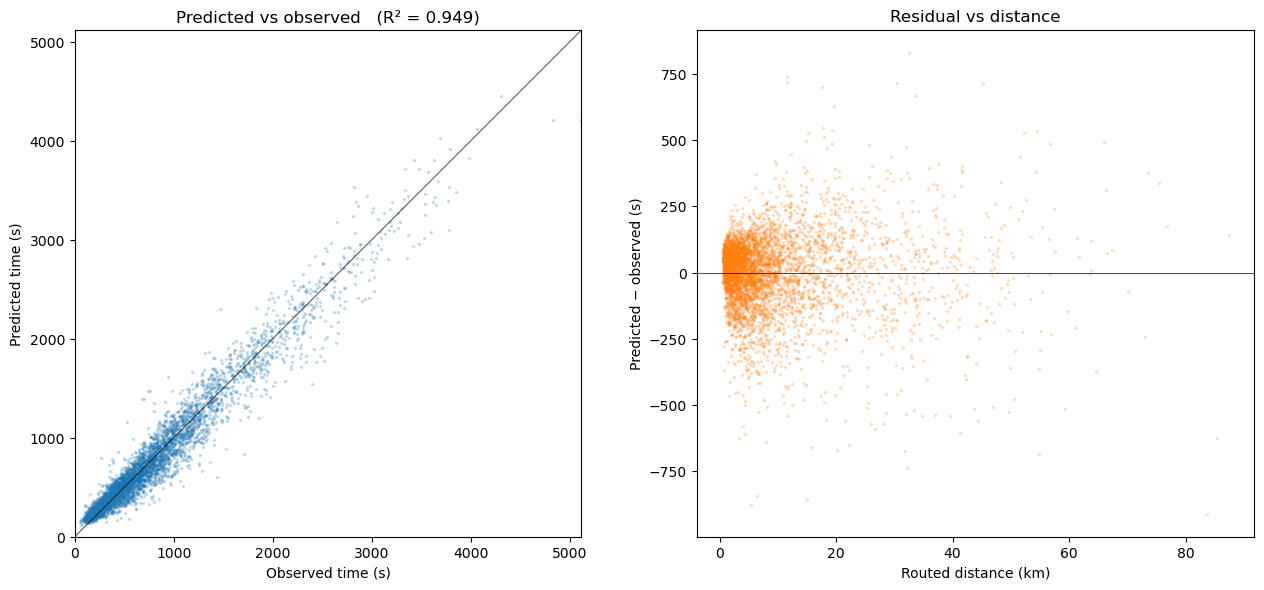

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

# Scatter
ax = axes[0]
ax.scatter(result.observed_times, result.predicted_times,
           s=2, alpha=0.2, color='tab:blue')
lim = max(result.observed_times.max(), result.predicted_times.max())
ax.plot([0, lim], [0, lim], color='black', linewidth=0.5)
ax.set_xlabel('Observed time (s)')
ax.set_ylabel('Predicted time (s)')
ax.set_title(f'Predicted vs observed   (R² = {result.r_squared:.3f})')
ax.set_xlim(0, lim); ax.set_ylim(0, lim)
ax.set_aspect('equal')

# Residual vs distance
ax = axes[1]
residuals = result.predicted_times - result.observed_times
ax.scatter(result.routed_distances / 1000, residuals,
           s=2, alpha=0.2, color='tab:orange')
ax.axhline(0, color='black', linewidth=0.5)
ax.set_xlabel('Routed distance (km)')
ax.set_ylabel('Predicted − observed (s)')
ax.set_title('Residual vs distance')

plt.tight_layout()
plt.show()

## What this notebook does NOT do

This is a self-contained demo of one library capability — calibrating
per-edge durations against observed point-to-point travel times. To
keep it readable as a tutorial, it deliberately omits things that
matter for production:

- **No road_stress / traffic-flow features.** The library's
  `calibrate_edge_weights` accepts arbitrary multiplier features, so a
  `road_stress` AADT estimate (see `road_stress.ipynb`) can enter
  through a BPR-style `(V/C)²` transform to capture congestion. The
  production lumos pipeline does this. Showcase keeps the model
  interpretable.
- **No iterative refinement on stricter trip filters.** Production
  typically iterates filters (drop trip outliers, retain only trips
  within a polygon, etc.) — we use a single set here.
- **Output not consumed by `accessibility.ipynb`.** That notebook
  uses published-paper coefficients instead. Each showcase notebook
  stands alone; they aren't wired into a pipeline.

For an example of these pieces wired into a full production stack
with `aperta_lab` scaffolding (scenario configs, typed I/O,
dependency tracking), see
[`aperta-lab/src/projects/lumos/calibration/`](https://github.com/mmiotti/aperta-lab/tree/main/src/projects/lumos/calibration).